In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv("../tissue_dataset.csv")
X = df.drop(columns = ["target", "target_actual"])
y = df["target"]
lasso_features = pd.read_csv("../results/lasso_feature_ranking.csv")

In [4]:
#Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators = 500, 
    class_weight = "balanced",
    random_state = 42,
    n_jobs = -1
)
rf.fit(X,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [16]:
#Ranking list
rf_importances = pd.DataFrame({
    "miRNA": X.columns,
    "Importance": rf.feature_importances_
})

rf_importances = rf_importances.sort_values(
    by = "Importance",
    ascending = False
)

rf_importances.reset_index(
    drop=True,
    inplace = True
)
rf_importances.insert(
    0,
    "Rank",
    range(1, len(rf_importances) + 1)
)
rf_importances.head(20)

,Rank,miRNA,Importance
0,1,42970 : hsa-miR-744-3p,0.014005
1,2,17875 : hsa-miR-500a-5p,0.013438
2,3,46647 : hsa-miR-1324,0.012218
3,4,46295 : hsa-miR-1286,0.012214
4,5,42852 : hsa-miR-760,0.011996
5,6,11102 : hsa-miR-410,0.011558
6,7,147709 : hsa-miR-3185,0.011262
7,8,168875 : hsa-miR-5091,0.011072
8,9,169159 : hsa-miR-4521,0.011045
9,10,42734 : hsa-miR-2110,0.010954


In [12]:
#Save Ranking list
rf_importances.to_csv(
    "../results/rf_importances_ranking.csv",
    index=False
)

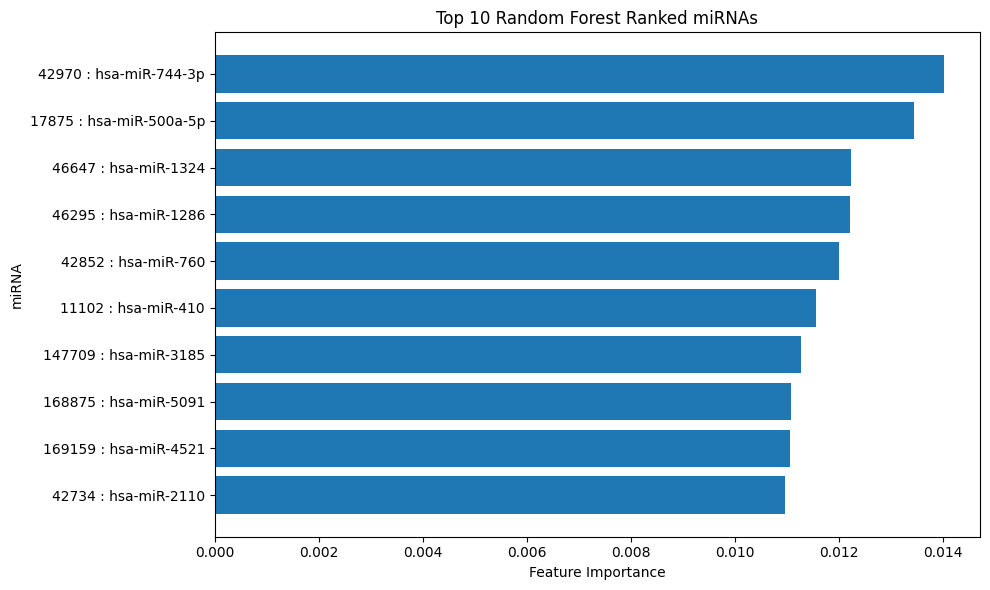

In [15]:
top10 = rf_importances.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["miRNA"],
    top10["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("miRNA")
plt.title("Top 10 Random Forest Ranked miRNAs")

plt.gca().invert_yaxis()
plt.savefig(
    "../figures/RF_top10",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

In [23]:
#Consensus Biomarker set 1
lasso_set = set(
    lasso_features["miRNA"]
)

rf_top20 = set(
    rf_importances.head(20)["miRNA"]
)

lasso_set.intersection(
    rf_top20
)

{'145677 : hsa-miR-139-5p',
 '147709 : hsa-miR-3185',
 '148228 : hsa-miR-3656',
 '168626 : hsa-miR-4662a-5p',
 '168791 : hsa-miR-4785'}

## Random Forest Feature Ranking Summary

* Data: 133 samples, 1926 miRNAs
* Model: Random Forest Classifier
* Trees: 500
* Class Weight: Balanced
* Feature Ranking Metric: Mean Decrease in Impurity (MDI)

### Key Observation

Random Forest assigned importance scores to all 1926 miRNAs and identified several highly ranked features, including hsa-miR-744-3p, hsa-miR-500a-5p, hsa-miR-1324, and hsa-miR-3185. Comparison with LASSO revealed five overlapping miRNAs: hsa-miR-139-5p, hsa-miR-3185, hsa-miR-3656, hsa-miR-4662a-5p, and hsa-miR-4785.

These overlapping features represent stronger candidate biomarkers because they were independently identified by both linear and tree-based feature ranking approaches.
